100%|██████████| 170M/170M [00:17<00:00, 9.80MB/s]


Epoch 1: Loss=1.6993, Accuracy=40.15%
Epoch 2: Loss=1.4819, Accuracy=48.08%
Epoch 3: Loss=1.3833, Accuracy=51.77%
Epoch 4: Loss=1.3126, Accuracy=54.21%
Epoch 5: Loss=1.2547, Accuracy=56.53%
Epoch 6: Loss=1.2094, Accuracy=57.94%
Epoch 7: Loss=1.1603, Accuracy=59.61%
Epoch 8: Loss=1.1176, Accuracy=61.28%
Epoch 9: Loss=1.0825, Accuracy=62.54%
Epoch 10: Loss=1.0431, Accuracy=63.82%
Epoch 1: Loss=1.6419, Accuracy=42.32%
Epoch 2: Loss=1.4378, Accuracy=49.80%
Epoch 3: Loss=1.3466, Accuracy=53.12%
Epoch 4: Loss=1.2788, Accuracy=55.47%
Epoch 5: Loss=1.2175, Accuracy=57.48%
Epoch 6: Loss=1.1633, Accuracy=59.61%
Epoch 7: Loss=1.1130, Accuracy=61.58%
Epoch 8: Loss=1.0584, Accuracy=63.44%
Epoch 9: Loss=1.0242, Accuracy=64.74%
Epoch 10: Loss=0.9758, Accuracy=66.26%


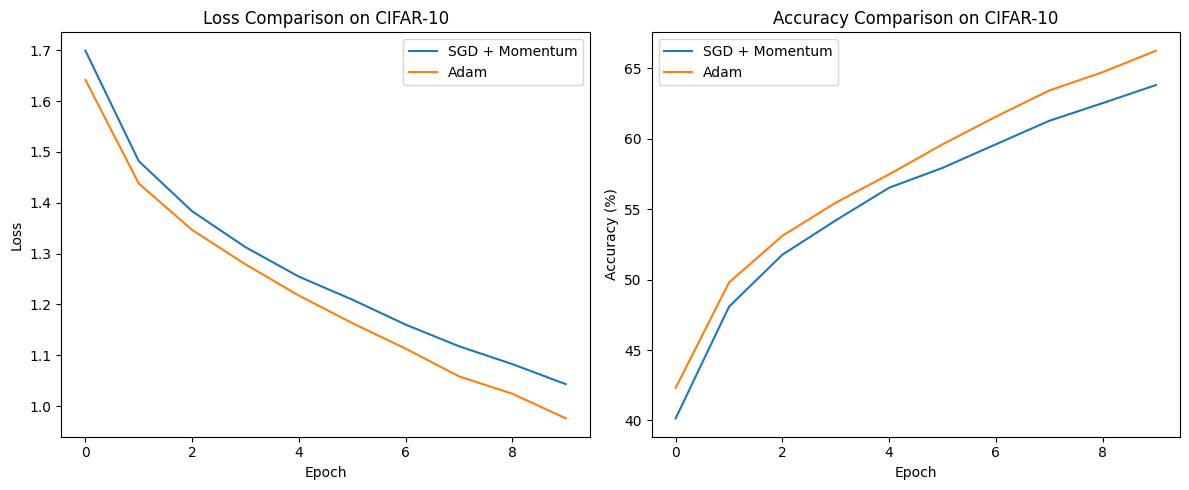

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device and dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, transform=transform, download=True
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True
)

# MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(self.flatten(x))

# Training function
def train(model, optimizer, epochs=10):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    losses, accuracies = [], []

    for epoch in range(epochs):
        total_loss = correct = total = 0
        model.train()

        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(trainloader)
        accuracy = 100 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Accuracy={accuracy:.2f}%")

    return losses, accuracies

# SGD + Momentum
model_sgd = MLP()
sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
losses_sgd, acc_sgd = train(model_sgd, sgd)

# Adam
model_adam = MLP()
adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam, acc_adam = train(model_adam, adam)

# Comparison plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_sgd, label="SGD + Momentum")
plt.plot(losses_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_sgd, label="SGD + Momentum")
plt.plot(acc_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10")
plt.legend()

plt.tight_layout()
plt.show()